In [5]:
import torch
from models.GPTModel import GPTModel
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "num_layers": 12,
    "num_heads": 12,
    "emb_dim": 768,
    "context_length": 256,
    "dropout": 0.1,
    "num_classes": 2,
    'bias':False
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
model.eval()

GPTModel(
  (tok_embedding): Embedding(50257, 768)
  (pos_embedding): Embedding(256, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attention): MultiHeadAttention(
        (w_q): Linear(in_features=768, out_features=768, bias=False)
        (w_k): Linear(in_features=768, out_features=768, bias=False)
        (w_v): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attention): MultiHeadAttention(
        (w_q): Linear(in_feat

In [6]:
file_path = "datasets/the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()
train_ratio = 0.9
split_idx = int(len(text) * train_ratio)
train_data = text[:split_idx]
val_data = text[split_idx:]

In [7]:
from chapter2.dataloader import create_dataloader
torch.manual_seed(123)
train_loader = create_dataloader(train_data, batch_size=2, max_length=GPT_CONFIG_124M['context_length'], 
                                 stride=GPT_CONFIG_124M['context_length'], shuffle=True, drop_last=True, num_workers=0)
val_loader = create_dataloader(val_data, batch_size=2, max_length=GPT_CONFIG_124M['context_length'], 
                               stride=GPT_CONFIG_124M['context_length'], shuffle=False, drop_last=True, num_workers=0)

## 学习率预热 + 余弦衰减

In [ ]:
n_epochs = 15
init_lr = 1e-4
peak_lr = 1e-2
total_steps = n_epochs * len(train_loader)
warmup_steps = int(0.2 * total_steps)


27


In [12]:
import math
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)
lr_increment = (peak_lr - init_lr) / warmup_steps
min_lr = 0.1 * init_lr  
global_step = -1
track_lr = []

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1
        
        if global_step < warmup_steps:
            lr = init_lr + lr_increment * global_step
        else:
            progress = (global_step - warmup_steps) / (total_steps - warmup_steps)
            lr = min_lr + (peak_lr - min_lr) * 0.5 * (1.0 + math.cos(progress * math.pi))
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
        track_lr.append(lr)

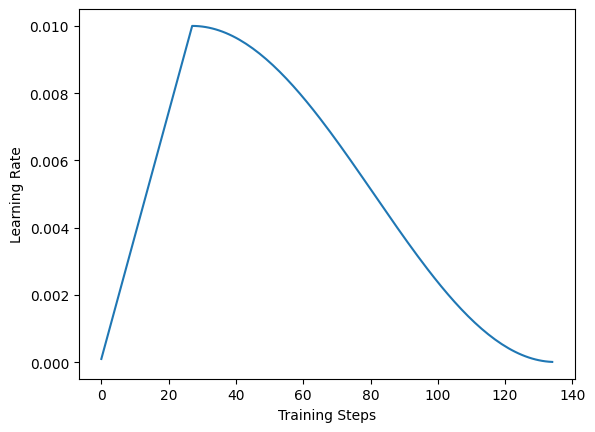

In [13]:
import matplotlib.pyplot as plt
plt.ylabel("Learning Rate")
plt.xlabel("Training Steps")
plt.plot(range(total_steps), track_lr)
plt.show()

## 梯度裁剪

In [15]:
from chapter5.calc_loss import calc_loss
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
loss = calc_loss(input_batch, target_batch, model, device)
loss.backward()
def find_max_gradient(model):
    max_grad = 0.0
    for param in model.parameters():
        if param.grad is not None:
            grad_values = param.grad.data.flatten()
            param_max_grad = grad_values.max()
            if param_max_grad > max_grad:
                max_grad = param_max_grad
    return max_grad
print("Max gradient:", find_max_gradient(model))

Max gradient: tensor(0.0421, device='cuda:0')


In [ ]:
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
print("Max gradient after clipping:", find_max_gradient(model))

Max gradient after clipping: tensor(0.0189, device='cuda:0')


: 